In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import xml.etree.ElementTree as ET
from tqdm.auto import tqdm
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/hassan/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3090


# Dataset Configuration

In [2]:
# Dataset paths
DATA_DIR = os.path.expanduser('./data')
IMAGES_DIR = os.path.join(DATA_DIR, 'images', 'Images')
ANNOTATIONS_DIR = os.path.join(DATA_DIR, 'annotations', 'Annotation')

# Hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_WORKERS = 4

# Create output directory for results
OUTPUT_DIR = os.path.expanduser('./results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Images directory: {IMAGES_DIR}")
print(f"Annotations directory: {ANNOTATIONS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Images directory: ./data/images/Images
Annotations directory: ./data/annotations/Annotation
Output directory: ./results


# Explore Dataset Structure

In [3]:
# Explore the dataset structure
def explore_dataset():
    breeds = sorted(os.listdir(IMAGES_DIR))
    print(f"Total number of breeds: {len(breeds)}")
    print(f"\nFirst 10 breeds: {breeds[:10]}")
    
    # Count images per breed
    breed_counts = {}
    for breed in breeds:
        breed_path = os.path.join(IMAGES_DIR, breed)
        if os.path.isdir(breed_path):
            breed_counts[breed] = len(os.listdir(breed_path))
    
    # Display statistics
    counts = list(breed_counts.values())
    print(f"\nTotal images: {sum(counts)}")
    print(f"Average images per breed: {np.mean(counts):.2f}")
    print(f"Min images per breed: {np.min(counts)}")
    print(f"Max images per breed: {np.max(counts)}")
    
    return breeds, breed_counts

breeds, breed_counts = explore_dataset()

Total number of breeds: 120

First 10 breeds: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']

Total images: 20580
Average images per breed: 171.50
Min images per breed: 148
Max images per breed: 252


# Visualize Dataset Distribution

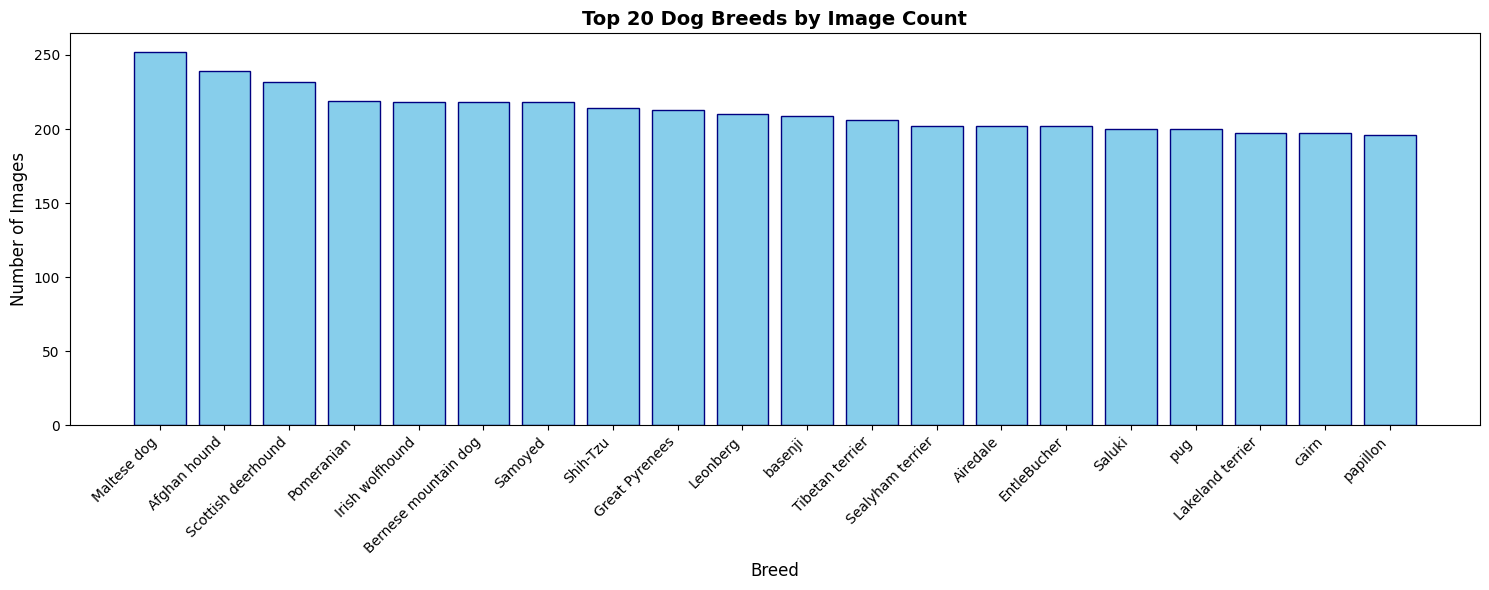

In [4]:
# Visualize breed distribution
plt.figure(figsize=(15, 6))
breeds_sorted = sorted(breed_counts.items(), key=lambda x: x[1], reverse=True)
breed_names = [b[0].split('-', 1)[1].replace('_', ' ') for b in breeds_sorted[:20]]
breed_vals = [b[1] for b in breeds_sorted[:20]]

plt.bar(range(len(breed_names)), breed_vals, color='skyblue', edgecolor='navy')
plt.xlabel('Breed', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Top 20 Dog Breeds by Image Count', fontsize=14, fontweight='bold')
plt.xticks(range(len(breed_names)), breed_names, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'breed_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Parse XML Annotations

In [5]:
# def parse_annotation(xml_file):
#     """Parse XML annotation file to extract bounding box"""
#     tree = ET.parse(xml_file)
#     root = tree.getroot()
    
#     # Extract bounding box
#     bndbox = root.find('object').find('bndbox')
#     xmin = int(bndbox.find('xmin').text)
#     ymin = int(bndbox.find('ymin').text)
#     xmax = int(bndbox.find('xmax').text)
#     ymax = int(bndbox.find('ymax').text)
    
#     return {'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax}

# # Test parsing
# test_breed = breeds[0]
# test_annotation = os.path.join(ANNOTATIONS_DIR, test_breed, os.listdir(os.path.join(ANNOTATIONS_DIR, test_breed))[0])
# test_bbox = parse_annotation(test_annotation)
# print(f"Sample bounding box: {test_bbox}")

# Create Dataset Class

In [6]:
class StanfordDogsDataset(Dataset):
    """Stanford Dogs Dataset"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("Dataset class defined successfully!")

Dataset class defined successfully!


# Prepare Data Splits

In [7]:
def prepare_data_splits():
    """Prepare train, validation, and test splits"""
    
    # Collect all image paths and labels
    all_image_paths = []
    all_labels = []
    breed_to_idx = {breed: idx for idx, breed in enumerate(sorted(breeds))}
    
    for breed in tqdm(sorted(breeds), desc="Loading dataset"):
        breed_dir = os.path.join(IMAGES_DIR, breed)
        if not os.path.isdir(breed_dir):
            continue
        
        for img_name in os.listdir(breed_dir):
            img_path = os.path.join(breed_dir, img_name)
            all_image_paths.append(img_path)
            all_labels.append(breed_to_idx[breed])
    
    # Convert to numpy arrays
    all_image_paths = np.array(all_image_paths)
    all_labels = np.array(all_labels)
    
    # Split: 70% train, 15% validation, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Number of classes: {len(breed_to_idx)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, breed_to_idx

X_train, X_val, X_test, y_train, y_val, y_test, breed_to_idx = prepare_data_splits()
idx_to_breed = {v: k for k, v in breed_to_idx.items()}

Loading dataset: 100%|██████████| 120/120 [00:00<00:00, 2062.50it/s]

Training samples: 16464
Validation samples: 2058
Test samples: 2058
Number of classes: 120


# Data Transforms

In [8]:
# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined successfully!")

Transforms defined successfully!


# Create DataLoaders

In [9]:
# Create datasets
train_dataset = StanfordDogsDataset(X_train, y_train, transform=train_transform)
val_dataset = StanfordDogsDataset(X_val, y_val, transform=val_test_transform)
test_dataset = StanfordDogsDataset(X_test, y_test, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1029
Validation batches: 129
Test batches: 129


# Visualize Sample Images

#  Model Architectures

In [10]:
def create_model(model_name, num_classes, pretrained=False):
    if model_name == 'resnet50':
        model = models.resnet50(weights=None if not pretrained else models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'resnet101':
        model = models.resnet101(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    # elif model_name == 'densenet121':
    #     model = models.densenet121(pretrained=pretrained)
    #     model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    # elif model_name == 'efficientnet_b0':
    #     model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes)
        
    elif model_name == 'efficientnet_b3':
        model = timm.create_model('efficientnet_b3', pretrained=pretrained, num_classes=num_classes)
        
    # elif model_name == 'vit_base':
    #     model = timm.create_model('vit_base_patch16_224', pretrained=pretrained, num_classes=num_classes)
        
    else:
        raise ValueError(f"Model {model_name} not supported")
    
    return model

# Test model creation
num_classes = len(breed_to_idx)
test_model = create_model('efficientnet_b3', num_classes)
print(f"ResNet50 created successfully with {num_classes} output classes")
del test_model

ResNet50 created successfully with 120 output classes


# Training Function

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{running_loss/len(dataloader):.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training function defined!")

Training function defined!


# Validation Function

In [12]:
def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

print("Validation function defined!")

Validation function defined!


# Full Training Loop

In [13]:
def train_model(model, model_name, train_loader, val_loader, num_epochs, device):
    """Complete training loop"""
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_path = os.path.join(OUTPUT_DIR, f'{model_name}_best.pth')
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ Best model saved with Val Acc: {best_val_acc:.2f}%")
        
        print()
    
    print(f"Training completed! Best Val Acc: {best_val_acc:.2f}%\n")
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    
    return model, history

print("Training loop defined!")

Training loop defined!


# Train Baseline CNN - ResNet50

In [14]:
# Create and train ResNet50
print("Creating efficientnet_b3 model...")
resnet50 = create_model('efficientnet_b3', num_classes, pretrained=False)

print(f"Model parameters: {sum(p.numel() for p in resnet50.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet50.parameters() if p.requires_grad):,}")

# Train the model
resnet50, resnet50_history = train_model(
    resnet50, 'efficientnet_b3', train_loader, val_loader, NUM_EPOCHS, device
)

Creating efficientnet_b3 model...
Model parameters: 10,880,672
Trainable parameters: 10,880,672

Training efficientnet_b3

Epoch 1/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:03<00:00, 41.57it/s]


Train Loss: 4.7874 | Train Acc: 1.69%
Val Loss: 4.5642 | Val Acc: 2.58%
✓ Best model saved with Val Acc: 2.58%

Epoch 2/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 45.76it/s]


Train Loss: 4.5282 | Train Acc: 2.85%
Val Loss: 4.3432 | Val Acc: 3.84%
✓ Best model saved with Val Acc: 3.84%

Epoch 3/100
----------------------------------------


...

Train Loss: 0.7207 | Train Acc: 77.85%
Val Loss: 2.3801 | Val Acc: 47.67%

Epoch 99/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 51.82it/s]


Train Loss: 0.7116 | Train Acc: 77.68%
Val Loss: 2.3029 | Val Acc: 48.10%

Epoch 100/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 52.08it/s]


Train Loss: 0.7243 | Train Acc: 77.48%
Val Loss: 2.4461 | Val Acc: 47.91%

Training completed! Best Val Acc: 48.40%



# Plot Training Curves

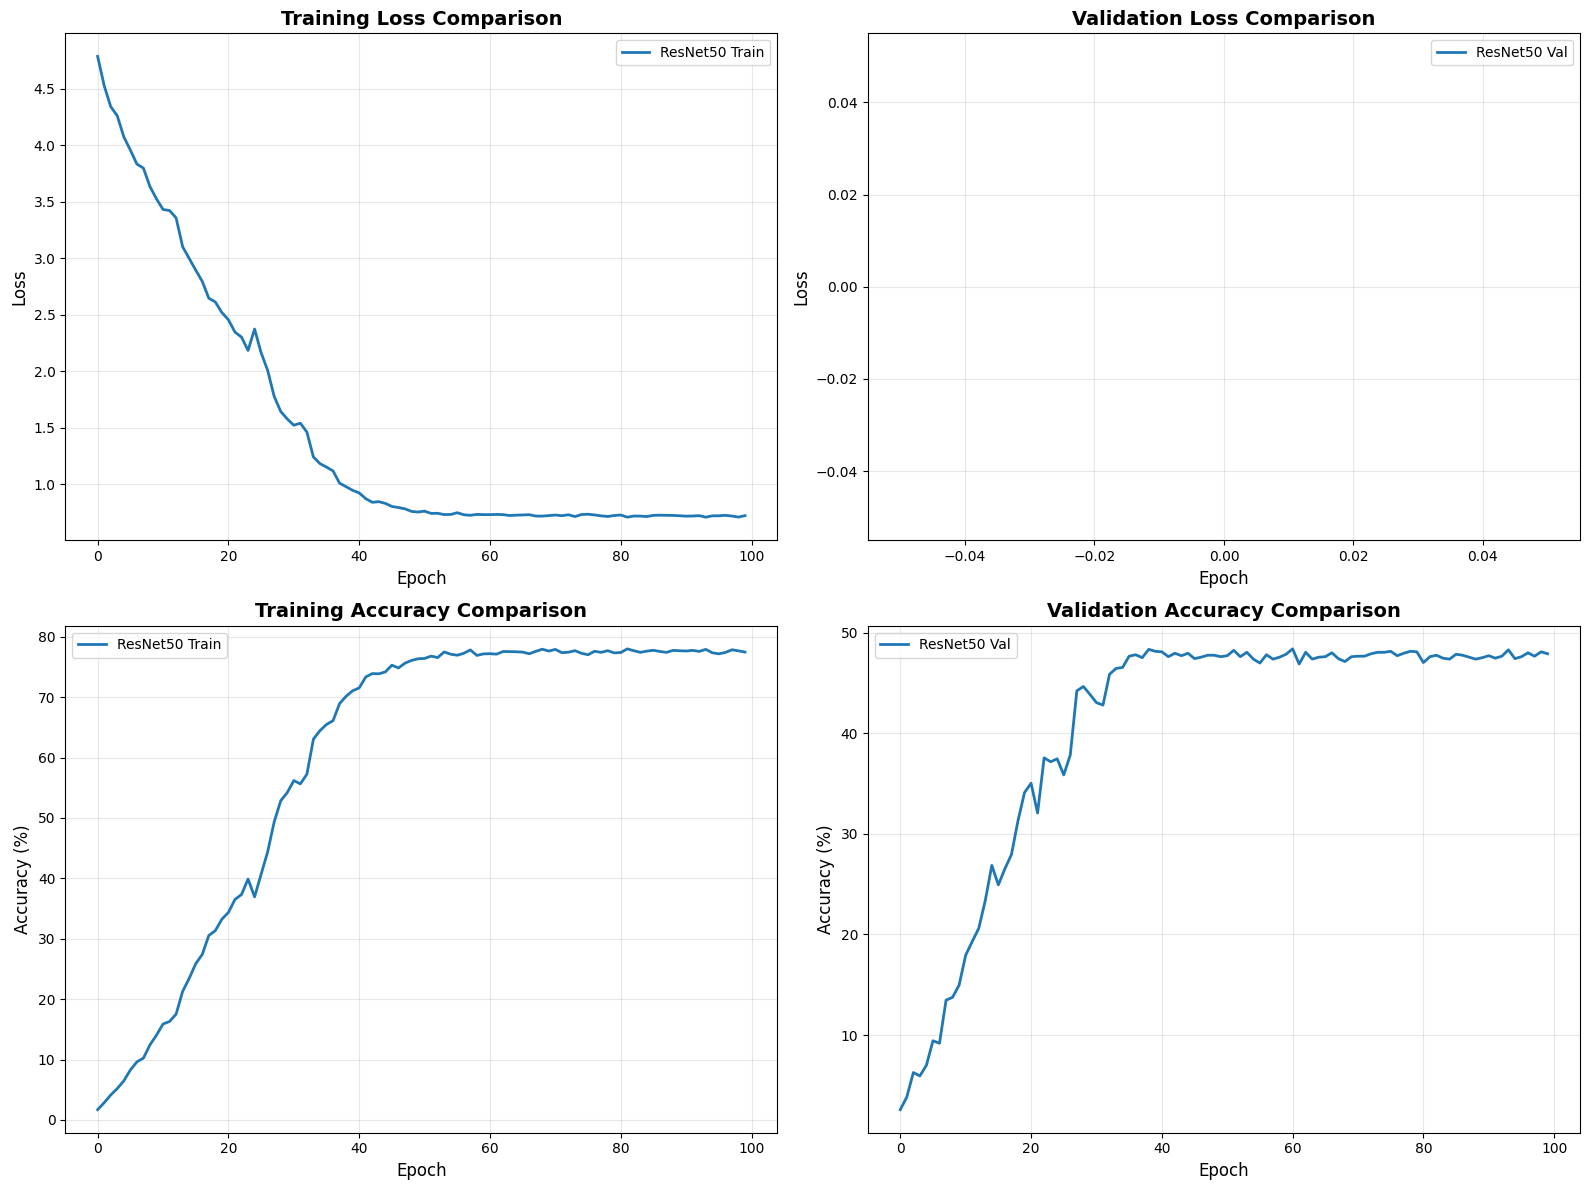

In [15]:
def plot_training_curves(histories, model_names):
    """Plot training and validation curves for all models"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Loss curves
    ax = axes[0, 0]
    for history, name in zip(histories, model_names):
        ax.plot(history['train_loss'], label=f'{name} Train', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    for history, name in zip(histories, model_names):
        ax.plot(history['val_loss'], label=f'{name} Val', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Accuracy curves
    ax = axes[1, 0]
    for history, name in zip(histories, model_names):
        ax.plot(history['train_acc'], label=f'{name} Train', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    for history, name in zip(histories, model_names):
        ax.plot(history['val_acc'], label=f'{name} Val', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Plot all training curves
histories = [resnet50_history]
model_names = ['ResNet50', 'DenseNet121', 'EfficientNet-B0', 'ViT-Base']

plot_training_curves(histories, model_names)

# Evaluate on Test Set

In [25]:
def evaluate_model(model, test_loader, device, model_name):
    """Evaluate model on test set"""
    
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, predictions, true_labels = validate(model, test_loader, criterion, device)
    
    # Calculate F1-score
    f1 = f1_score(true_labels, predictions, average='weighted')
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"F1-Score (weighted): {f1:.4f}")
    print(f"{'='*60}\n")
    
    return test_acc, f1, predictions, true_labels

# Evaluate all models
results = {}

print("Evaluating efficientnet_b3...")
results['efficientnet_b3'] = evaluate_model(resnet50, test_loader, device, 'efficientnet_b3')


Evaluating efficientnet_b3...


Validation: 100%|██████████| 129/129 [00:03<00:00, 42.46it/s]


efficientnet_b3 - Test Set Evaluation
Test Loss: 2.3107
Test Accuracy: 48.49%
F1-Score (weighted): 0.4825



# ResNet50 : Generate and plot confusion matrix

Generating predictions for efficientnet_b3...


Predicting: 100%|██████████| 129/129 [00:02<00:00, 46.00it/s]


Confusion matrix saved to ./results/confusion_matrix_resnet101.png


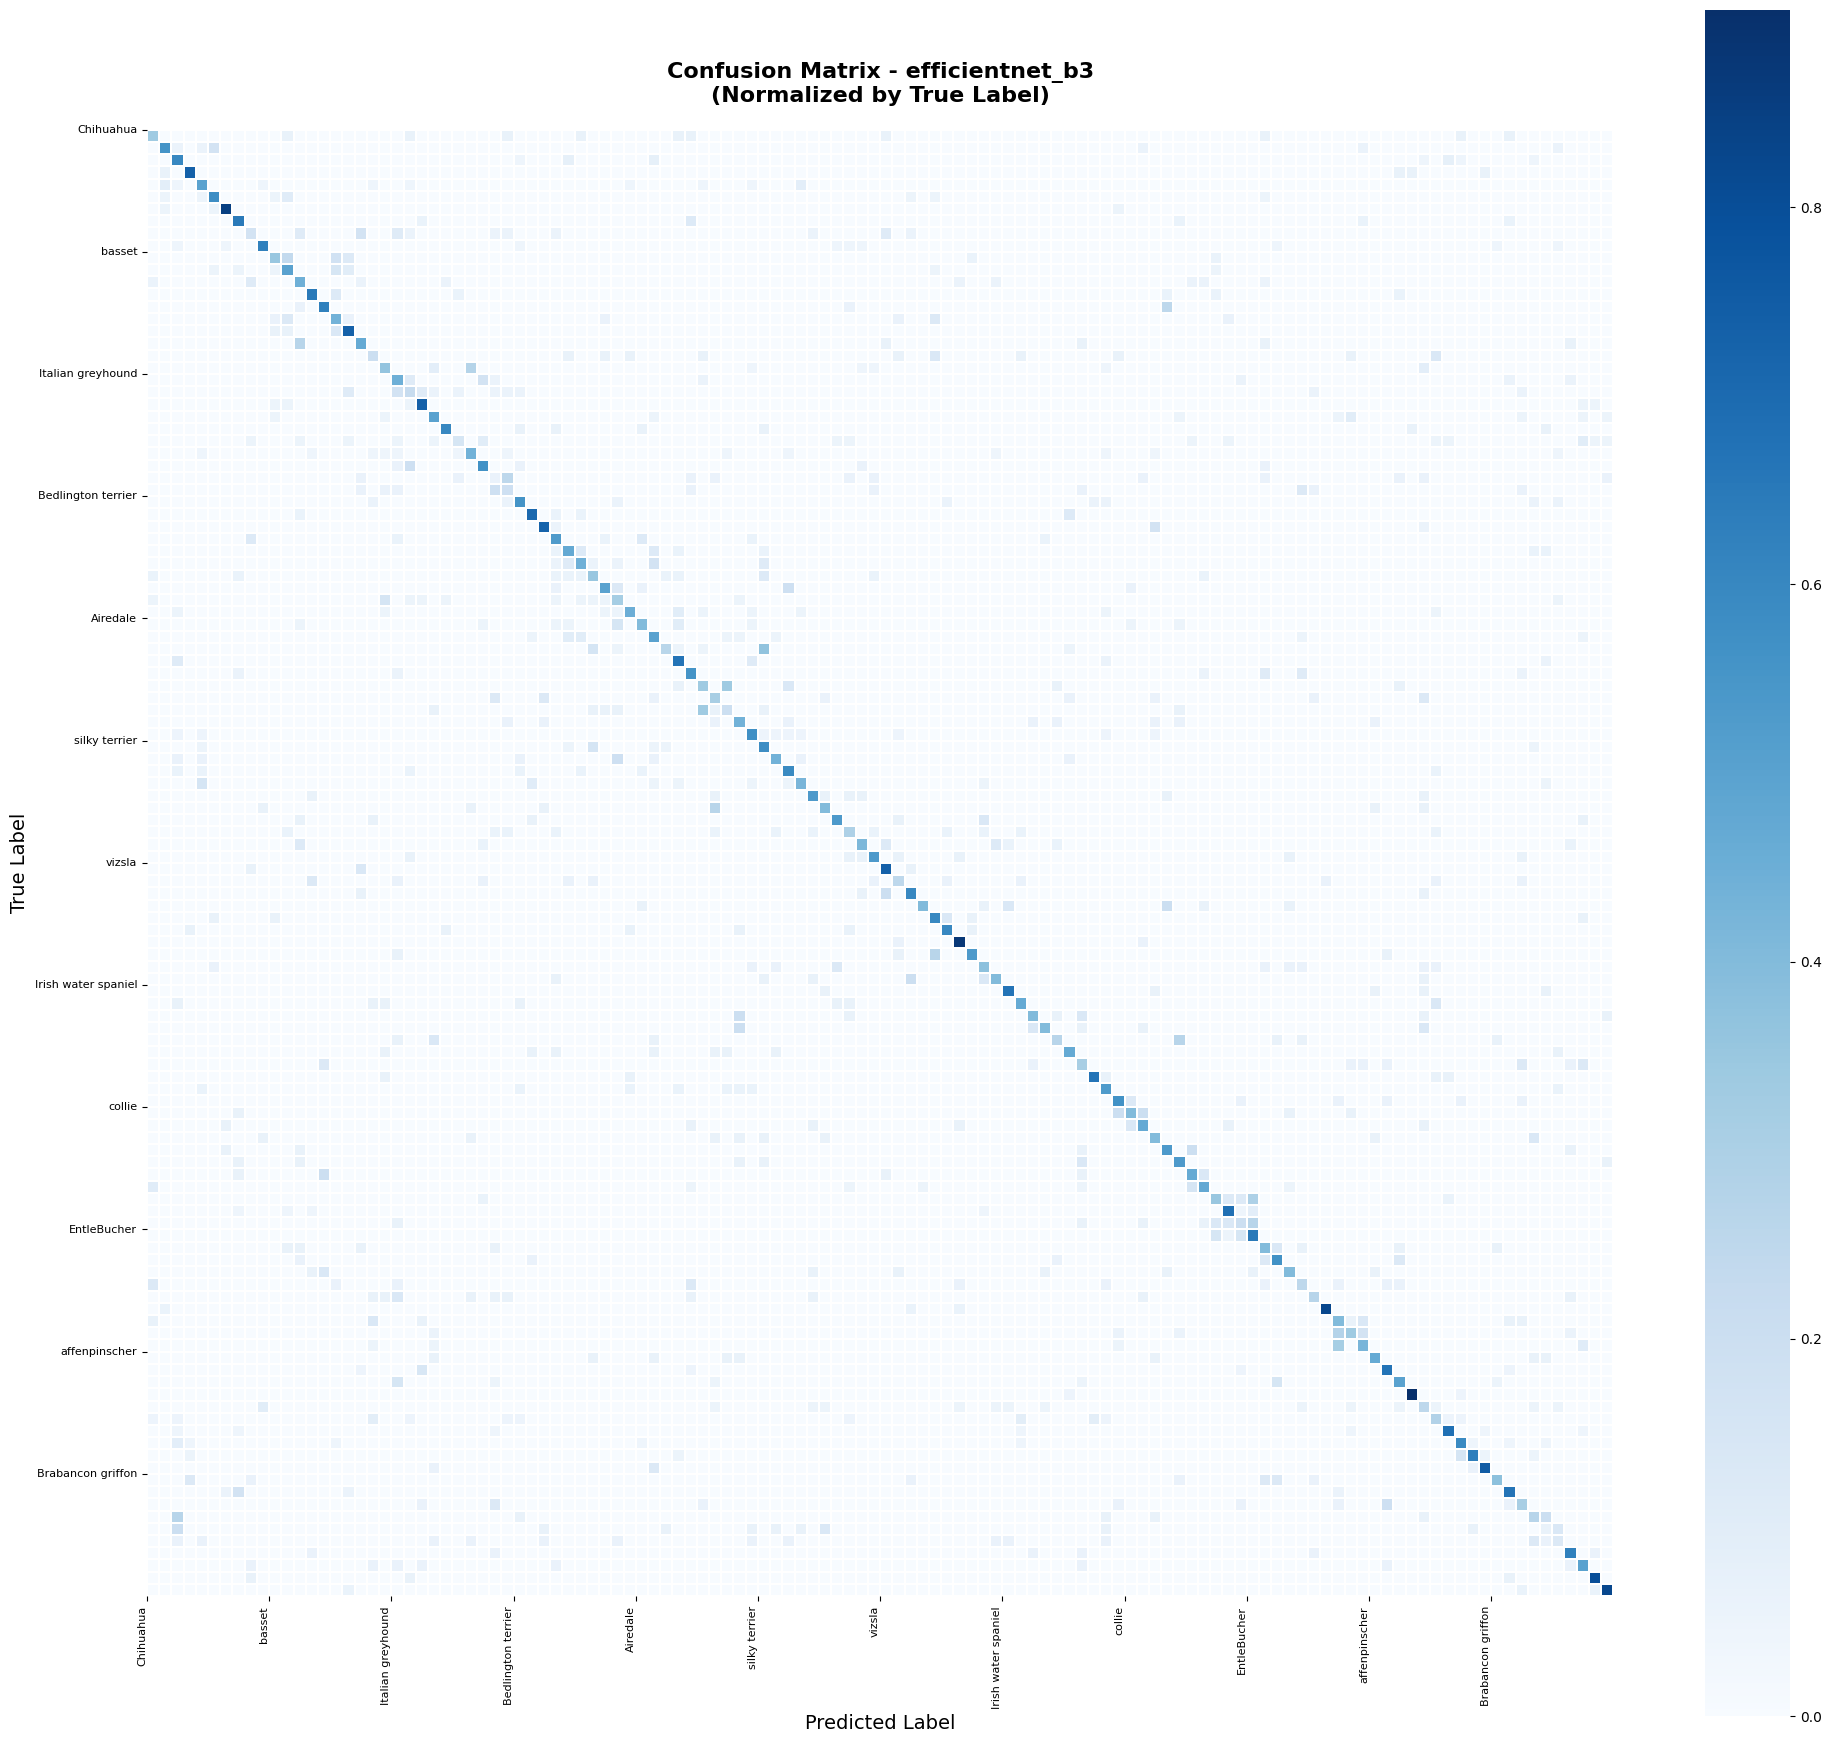


efficientnet_b3 - Per-Class Performance

Top 5 Best Performing Classes:
  Leonberg: 90.48%
  English springer: 87.50%
  papillon: 85.00%
  Saint Bernard: 82.35%
  African hunting dog: 82.35%

Bottom 5 Worst Performing Classes:
  Rhodesian ridgeback: 16.67%
  Saluki: 15.00%
  standard poodle: 12.50%
  miniature poodle: 6.67%
  Staffordshire bullterrier: 6.25%



In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, dataloader, device, model_name, breed_to_idx, save_path=None):
    """Generate and plot confusion matrix"""
    
    model.eval()
    all_preds = []
    all_labels = []
    
    # Get predictions
    print(f"Generating predictions for {model_name}...")
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Predicting'):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot confusion matrix
    plt.figure(figsize=(20, 18))
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='Blues', 
                cbar=True, square=True, linewidths=0.1)
    
    plt.title(f'Confusion Matrix - {model_name}\n(Normalized by True Label)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    
    # Add breed names on axes (every 10th breed for readability)
    breed_names = sorted(breed_to_idx.keys())
    tick_marks = np.arange(0, len(breed_names), 10)
    tick_labels = [breed_names[i].split('-', 1)[1].replace('_', ' ') for i in tick_marks]
    
    plt.xticks(tick_marks, tick_labels, rotation=90, ha='right', fontsize=8)
    plt.yticks(tick_marks, tick_labels, rotation=0, fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to {save_path}")
    
    plt.show()
    
    # Calculate per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Show top 5 and bottom 5 classes
    breed_names_clean = [b.split('-', 1)[1].replace('_', ' ') for b in breed_names]
    class_acc_dict = {breed_names_clean[i]: class_accuracy[i] for i in range(len(breed_names))}
    sorted_acc = sorted(class_acc_dict.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Per-Class Performance")
    print(f"{'='*60}")
    print("\nTop 5 Best Performing Classes:")
    for breed, acc in sorted_acc[:5]:
        print(f"  {breed}: {acc*100:.2f}%")
    
    print("\nBottom 5 Worst Performing Classes:")
    for breed, acc in sorted_acc[-5:]:
        print(f"  {breed}: {acc*100:.2f}%")
    print(f"{'='*60}\n")
    
    return cm, all_preds, all_labels

# Generate confusion matrix for ResNet50
cm_resnet50, preds_resnet50, labels_resnet50 = plot_confusion_matrix(
    resnet50, 
    test_loader, 
    device, 
    'efficientnet_b3',
    breed_to_idx,
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix_resnet101.png')
)

# Train EfficientNet Model

In [19]:
print("\n" + "="*60)
print("Training EfficientNet-B0 Model")
print("="*60 + "\n")

# Create EfficientNet-B0 model
print("Creating EfficientNet-B0 model...")
efficientnet = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)

print(f"Model parameters: {sum(p.numel() for p in efficientnet.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in efficientnet.parameters() if p.requires_grad):,}")

# Train the model
efficientnet, efficientnet_history = train_model(
    efficientnet, 
    'efficientnet_b0', 
    train_loader, 
    val_loader, 
    NUM_EPOCHS, 
    device
)

print("\nEfficientNet-B0 training completed!")


Training EfficientNet-B0 Model

Creating EfficientNet-B0 model...
Model parameters: 4,161,268
Trainable parameters: 4,161,268

Training efficientnet_b0

Epoch 1/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 59.38it/s]


Train Loss: 2.2122 | Train Acc: 41.59%
Val Loss: 1.4723 | Val Acc: 57.63%
✓ Best model saved with Val Acc: 57.63%

Epoch 2/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 56.91it/s]


Train Loss: 1.4213 | Train Acc: 58.71%
Val Loss: 1.4588 | Val Acc: 58.70%
✓ Best model saved with Val Acc: 58.70%

Epoch 3/100
----------------------------------------


...

Train Loss: 0.0069 | Train Acc: 99.81%
Val Loss: 1.3528 | Val Acc: 73.81%

Epoch 99/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 55.93it/s]


Train Loss: 0.0082 | Train Acc: 99.74%
Val Loss: 1.3518 | Val Acc: 74.00%

Epoch 100/100
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 52.93it/s]


Train Loss: 0.0085 | Train Acc: 99.74%
Val Loss: 1.3613 | Val Acc: 73.62%

Training completed! Best Val Acc: 74.25%


EfficientNet-B0 training completed!


# Plot EfficientNet Training & Validation Loss Curves

ValueError: x and y must have same first dimension, but have shapes (100,) and (0,)

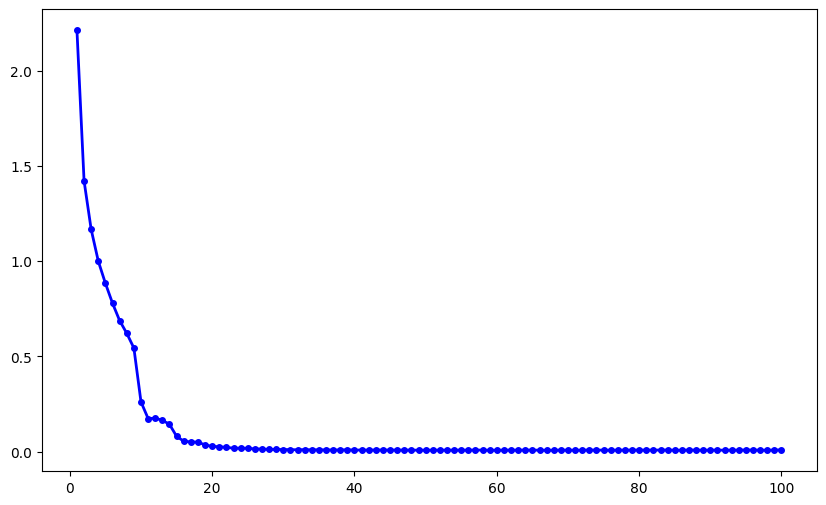

In [20]:
def plot_loss_curves(history, model_name):
    """Plot training and validation loss curves"""
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
    
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Training & Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add min loss annotations
    min_train_loss = min(history['train_loss'])
    min_val_loss = min(history['val_loss'])
    min_train_epoch = history['train_loss'].index(min_train_loss) + 1
    min_val_epoch = history['val_loss'].index(min_val_loss) + 1
    
    ax.axhline(y=min_train_loss, color='b', linestyle=':', alpha=0.5)
    ax.axhline(y=min_val_loss, color='r', linestyle=':', alpha=0.5)
    
    ax.text(0.02, 0.98, f'Min Train Loss: {min_train_loss:.4f} (Epoch {min_train_epoch})', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    ax.text(0.02, 0.88, f'Min Val Loss: {min_val_loss:.4f} (Epoch {min_val_epoch})', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name.lower().replace(" ", "_")}_loss_curves.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

# Plot loss curves for EfficientNet
plot_loss_curves(efficientnet_history, 'EfficientNet-B0')

# Plot EfficientNet Training & Validation Accuracy Curves

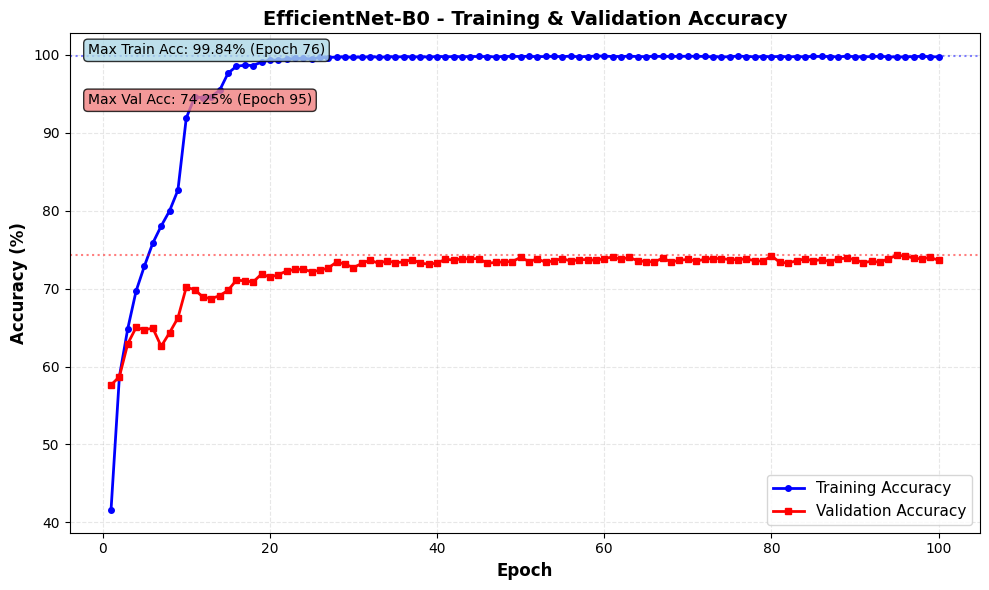

In [21]:
def plot_accuracy_curves(history, model_name):
    """Plot training and validation accuracy curves"""
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    epochs = range(1, len(history['train_acc']) + 1)
    
    ax.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2, marker='o', markersize=4)
    ax.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
    
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add max accuracy annotations
    max_train_acc = max(history['train_acc'])
    max_val_acc = max(history['val_acc'])
    max_train_epoch = history['train_acc'].index(max_train_acc) + 1
    max_val_epoch = history['val_acc'].index(max_val_acc) + 1
    
    ax.axhline(y=max_train_acc, color='b', linestyle=':', alpha=0.5)
    ax.axhline(y=max_val_acc, color='r', linestyle=':', alpha=0.5)
    
    ax.text(0.02, 0.98, f'Max Train Acc: {max_train_acc:.2f}% (Epoch {max_train_epoch})', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    ax.text(0.02, 0.88, f'Max Val Acc: {max_val_acc:.2f}% (Epoch {max_val_epoch})', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name.lower().replace(" ", "_")}_accuracy_curves.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

# Plot accuracy curves for EfficientNet
plot_accuracy_curves(efficientnet_history, 'EfficientNet-B0')

# Evaluate EfficientNet on Test Set

In [22]:
print("Evaluating EfficientNet-B0 on test set...")
results['EfficientNet-B0'] = evaluate_model(efficientnet, test_loader, device, 'EfficientNet-B0')

Evaluating EfficientNet-B0 on test set...


Validation: 100%|██████████| 129/129 [00:02<00:00, 52.98it/s]



EfficientNet-B0 - Test Set Evaluation
Test Loss: 1.2352
Test Accuracy: 74.93%
F1-Score (weighted): 0.7463



# Generate Confusion Matrix for EfficientNet

Generating predictions for EfficientNet-B0...


Predicting: 100%|██████████| 129/129 [00:02<00:00, 56.46it/s]


Confusion matrix saved to ./results/confusion_matrix_efficientnet_b0.png


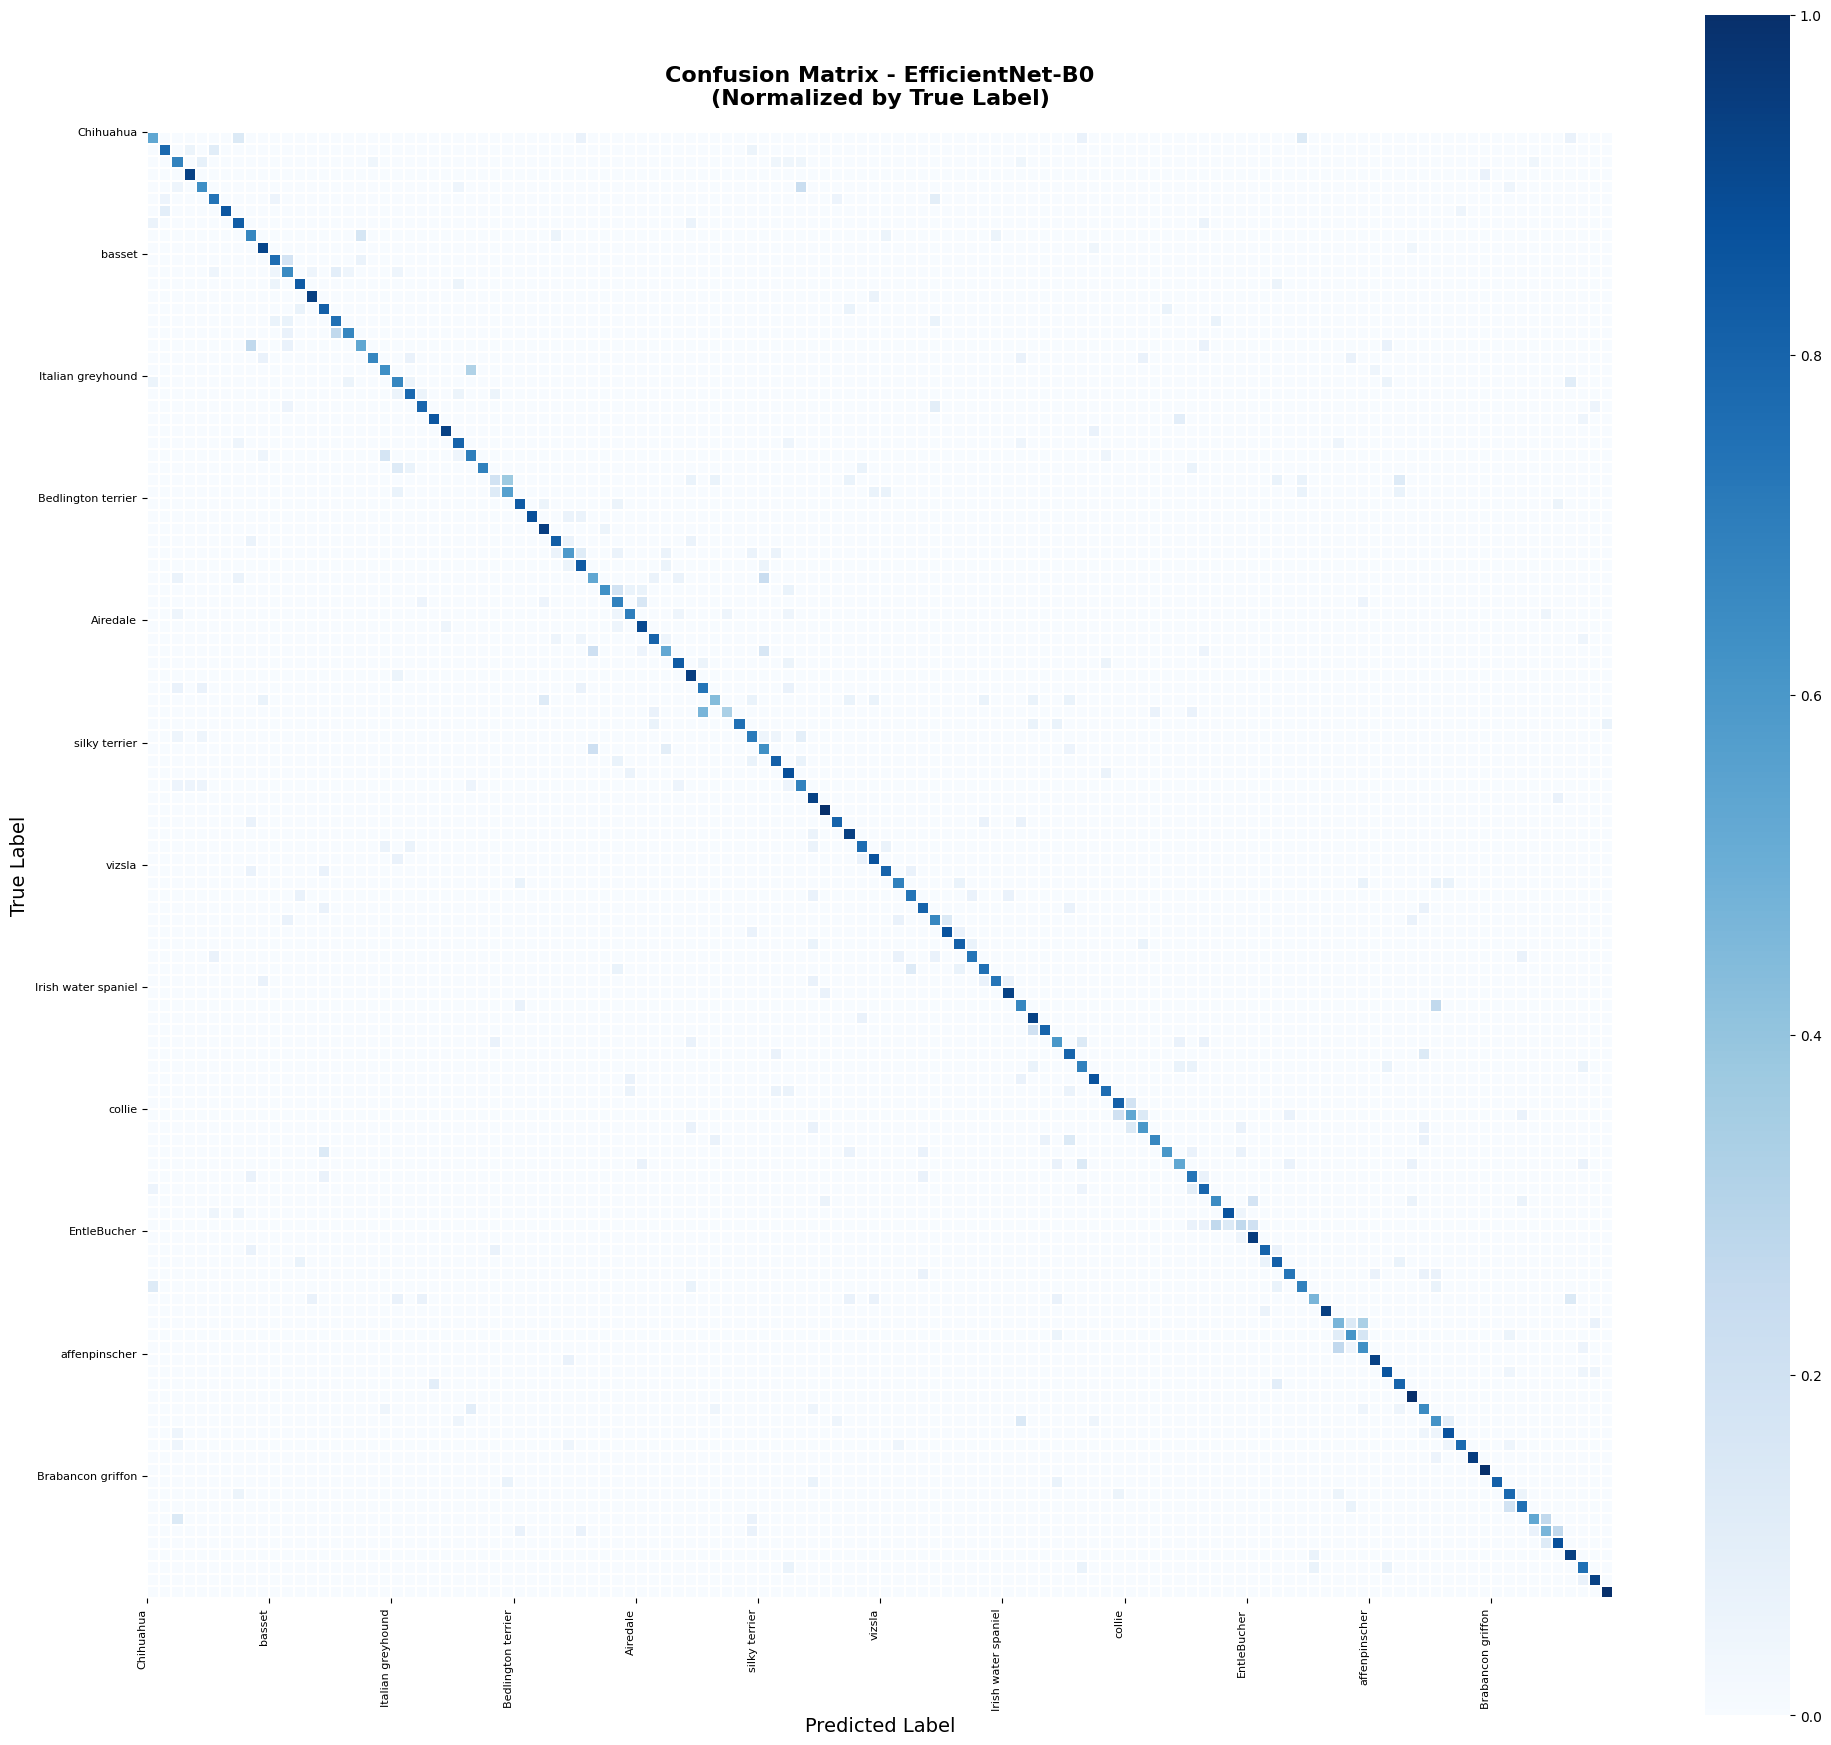


EfficientNet-B0 - Per-Class Performance

Top 5 Best Performing Classes:
  curly-coated retriever: 100.00%
  Leonberg: 100.00%
  keeshond: 100.00%
  African hunting dog: 100.00%
  EntleBucher: 95.00%

Bottom 5 Worst Performing Classes:
  miniature poodle: 46.67%
  giant schnauzer: 43.75%
  standard schnauzer: 33.33%
  Appenzeller: 26.67%
  Staffordshire bullterrier: 18.75%



In [23]:
# Generate confusion matrix for EfficientNet-B0
cm_efficientnet, preds_efficientnet, labels_efficientnet = plot_confusion_matrix(
    efficientnet, 
    test_loader, 
    device, 
    'EfficientNet-B0',
    breed_to_idx,
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix_efficientnet_b0.png')
)

# Compare ResNet50 vs EfficientNet Performance


MODEL COMPARISON SUMMARY

           Model  Test Accuracy (%)  F1-Score
EfficientNet-B0          74.927114  0.746290
       ResNet50          48.493683  0.482524



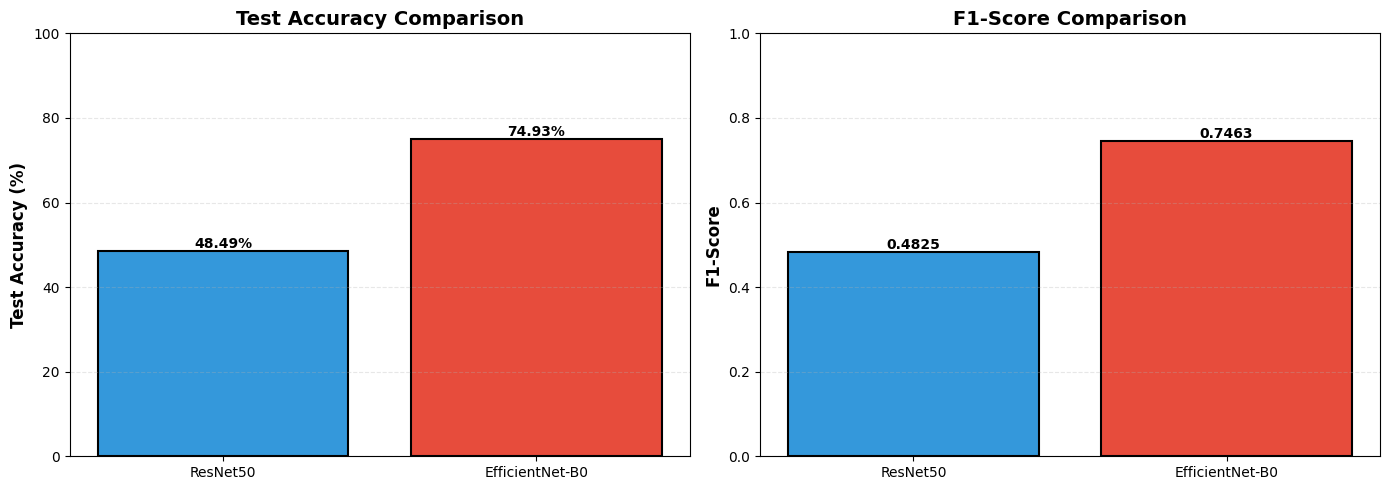


🏆 Best Model: EfficientNet-B0 with 74.93% test accuracy



In [24]:
def compare_models(results_dict):
    """Compare performance metrics of different models"""
    
    print("\n" + "="*70)
    print("MODEL COMPARISON SUMMARY")
    print("="*70)
    
    model_names = list(results_dict.keys())
    test_accs = [results_dict[model][0] for model in model_names]
    f1_scores = [results_dict[model][1] for model in model_names]
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': model_names,
        'Test Accuracy (%)': test_accs,
        'F1-Score': f1_scores
    })
    
    comparison_df = comparison_df.sort_values('Test Accuracy (%)', ascending=False)
    print("\n", comparison_df.to_string(index=False))
    print("="*70 + "\n")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy comparison
    ax = axes[0]
    bars = ax.bar(model_names, test_accs, color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold')
    
    # F1-Score comparison
    ax = axes[1]
    bars = ax.bar(model_names, f1_scores, color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
    ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Determine best model
    best_model = comparison_df.iloc[0]['Model']
    best_acc = comparison_df.iloc[0]['Test Accuracy (%)']
    
    print(f"\n🏆 Best Model: {best_model} with {best_acc:.2f}% test accuracy\n")

# Compare all models
compare_models(results)

# lot Combined Training Curves (ResNet50 vs EfficientN

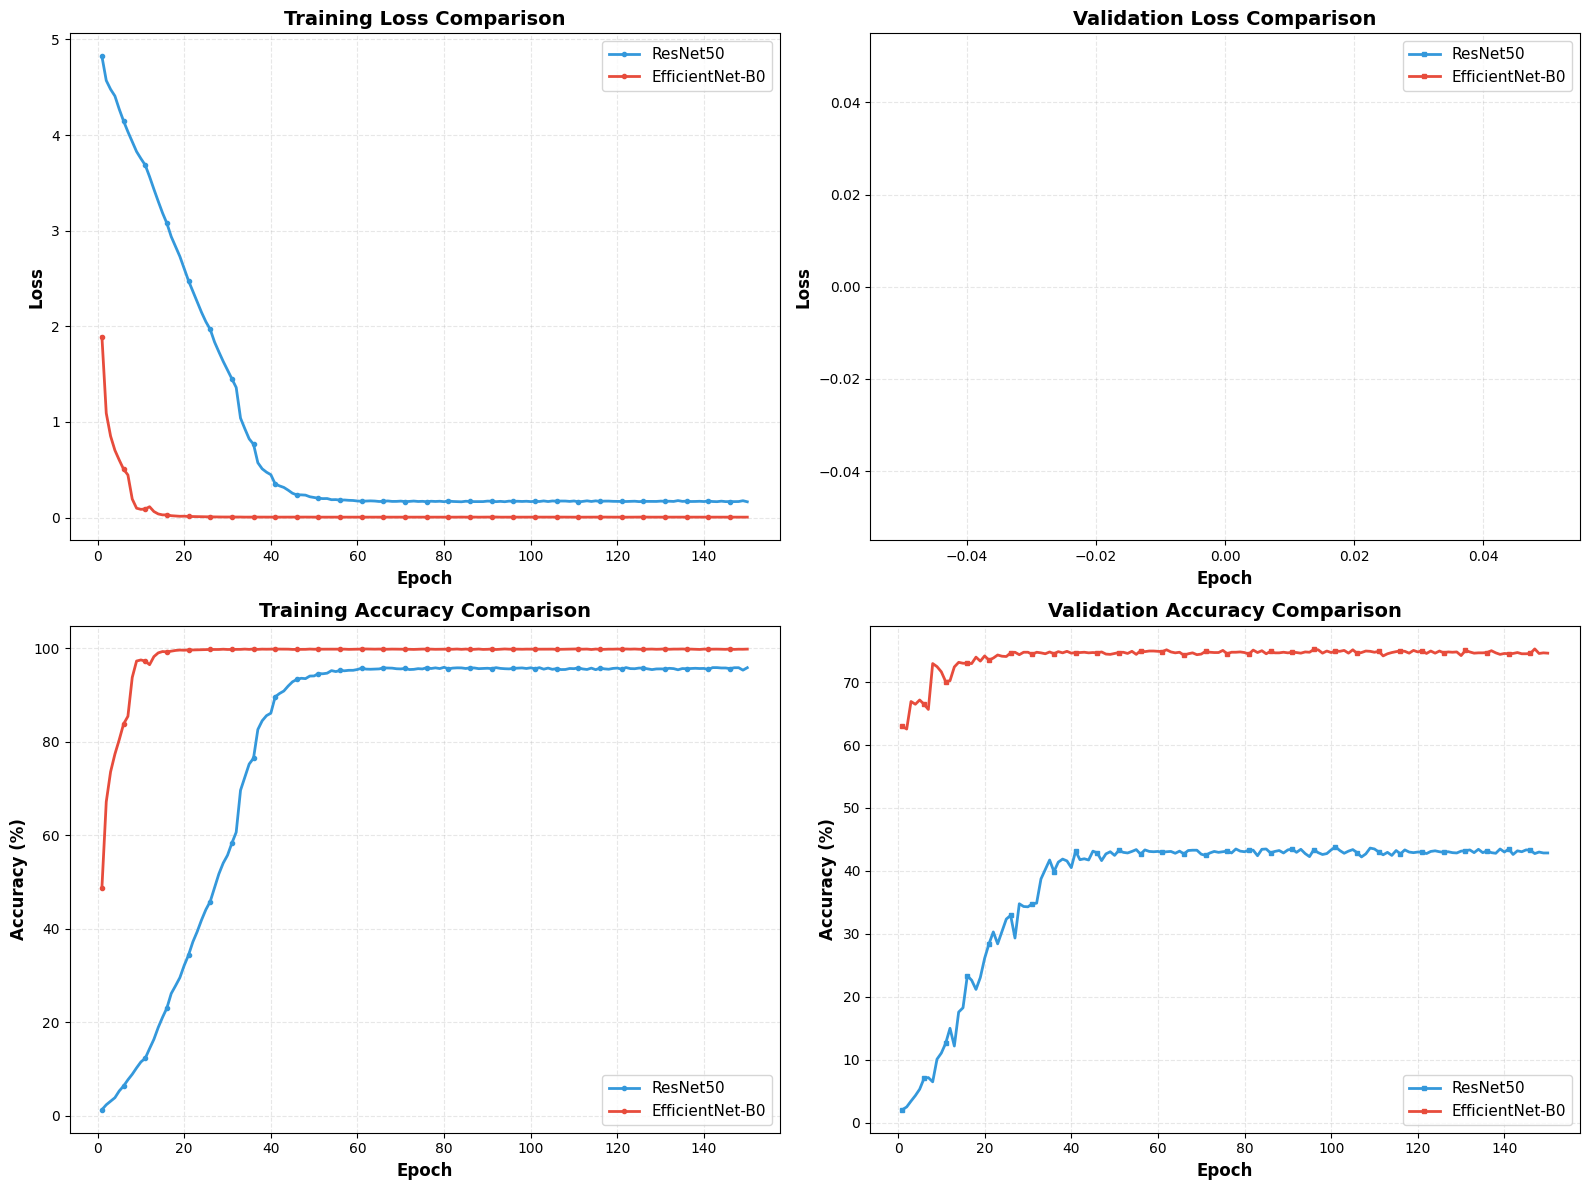

In [ ]:
def plot_combined_training_curves(histories, model_names):
    """Plot combined training curves for multiple models"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    # Training Loss
    ax = axes[0, 0]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], label=name, linewidth=2, 
                color=colors[i % len(colors)], marker='o', markersize=3, markevery=5)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Validation Loss
    ax = axes[0, 1]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['val_loss']) + 1)
        ax.plot(epochs, history['val_loss'], label=name, linewidth=2, 
                color=colors[i % len(colors)], marker='s', markersize=3, markevery=5)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Training Accuracy
    ax = axes[1, 0]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['train_acc']) + 1)
        ax.plot(epochs, history['train_acc'], label=name, linewidth=2, 
                color=colors[i % len(colors)], marker='o', markersize=3, markevery=5)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Validation Accuracy
    ax = axes[1, 1]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['val_acc']) + 1)
        ax.plot(epochs, history['val_acc'], label=name, linewidth=2, 
                color=colors[i % len(colors)], marker='s', markersize=3, markevery=5)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'combined_training_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Plot combined curves
histories = [resnet50_history, efficientnet_history]
model_names = ['ResNet50', 'EfficientNet-B0']
plot_combined_training_curves(histories, model_names)

# Improved Model : 

In [ ]:
def create_model_with_regularization(model_name, num_classes, pretrained=True, dropout_rate=0.5):
    """Create model with dropout regularization"""
    
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
        # Add dropout before final layer
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(num_features, num_classes)
        )
        
    elif model_name == 'efficientnet_b0':
        model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes, drop_rate=dropout_rate)
        
    return model

print("Enhanced model creation function defined!")

Enhanced model creation function defined!
